# AM-RELDEC: Agile Meta-RELDEC Validation

This notebook validates the `addn_algos/am_reldec.py` implementation against:
- Flooding BP (baseline)
- Residual-based cluster scheduling (RBP)
- RELDEC (single-SNR Q-learning)
- AM-RELDEC global policy (meta-trained across K SNRs)
- AM-RELDEC adapted local policy (online adaptation from pilots)

Uses the NR_1_0_32 base matrix lifted by Z=32.


In [1]:
import os, sys

nb_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(nb_dir, '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
print('Using project root:', project_root)

Using project root: /Users/rithvik/Documents/hnrs/Decoder


In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt

from utils.LDPC_encode import QCLDPCEncoder
from utils.awgn_channel import AWGNChannel
from utils.find_ber import findBER
from utils.res_cluster_picker import pick_max_avg_residual_cluster
from ldpc.bp_decoder import BpDecoder
from addn_algos.reldec import Reldec

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

## 1. Setup: Encoder, Decoder, Clusters

In [3]:
base_pc_matrix = '../pc_matrices/small_16.txt'
P = np.loadtxt(base_pc_matrix, dtype=int)
blocksize = 16  # lifting factor Z

encoder = QCLDPCEncoder(base_matrix=P, Z=blocksize)
H = encoder.H          # full binary parity-check matrix (m x n)
k = encoder.K          # number of information bits
m, n = H.shape
print(f'Code: [{n}, {k}]  H: {m}x{n}')

Initializing Encoder: Full Matrix Size 96x288, Message Bits: 192
  > Inverting Parity Matrix (this may take a moment for large Z)...
  > Computing Generator Matrix...
Encoder Ready.
Code: [288, 192]  H: 96x288


In [4]:
# z = 1: each check node is its own cluster (best performance per paper)
check_nodes = np.arange(m)
clusters = [[cn] for cn in check_nodes]   # list of singletons
print(f'Number of clusters: {len(clusters)}  (z=1)')

Number of clusters: 96  (z=1)


In [5]:
# Shared BpDecoder instance used by AmReldec
bp_decoder = BpDecoder(H)

# AmReldec parameters (paper recommendations)
ALPHA   = 0.5   # learning rate
BETA    = 0.9   # discount factor
EPSILON = 0.1   # exploration probability
L_MAX   = m     # steps per episode = num_clusters
L_MIN   = 1e-4  # early-termination loss threshold (AM-RELDEC)

reldec = Reldec(
    H=H,
    clusters=clusters,
    decoder=bp_decoder,
    alpha=ALPHA,
    beta=BETA,
    epsilon=EPSILON,
    l_max=L_MAX,
    l_min_loss=L_MIN,
)
print('Reldec initialised.')
print(f'Cluster VN sizes: min={min(len(v) for v in reldec.cluster_vns)},',
      f'max={max(len(v) for v in reldec.cluster_vns)},',
      f'mean={np.mean([len(v) for v in reldec.cluster_vns]):.1f}')

Reldec initialised.
Cluster VN sizes: min=8, max=9, mean=8.2


## 2. Generate Training and Test Data

In [6]:
# SNR grid
training_snrs = [4.0, 5.0, 6.0]   # K SNRs for AM-RELDEC
test_snrs     = [4, 5, 6, 7, 8]   # SNRs to evaluate BER
target_adapt_snr = 7.0             # SNR for online adaptation demo

N_TRAIN = 200    # training frames per SNR
N_TEST  = 1000   # test frames per SNR
N_PILOT = 20     # pilot frames for online adaptation
I_MAX   = 30     # maximum decoder iterations

# Training codewords (same for all SNRs)
message_train = np.random.randint(0, 2, (N_TRAIN, k))
codeword_train = encoder.encode(message_train)  # (N_TRAIN, n)
tx_train = 1 - 2 * codeword_train               # BPSK: 0->+1, 1->-1

# Training LLRs per SNR
llr_dict = {}
cwd_dict = {}
for snr in training_snrs:
    rx_llrs = AWGNChannel(tx_train, snr_db=snr)  # (N_TRAIN, n)
    llr_dict[snr] = [rx_llrs[i] for i in range(N_TRAIN)]
    cwd_dict[snr] = [codeword_train[i] for i in range(N_TRAIN)]

# Test frames (fresh random messages)
message_test = np.random.randint(0, 2, (N_TEST, k))
codeword_test = encoder.encode(message_test)
tx_test = 1 - 2 * codeword_test

# Pilot frames for adaptation
message_pilot = np.random.randint(0, 2, (N_PILOT, k))
codeword_pilot = encoder.encode(message_pilot)
tx_pilot = 1 - 2 * codeword_pilot
rx_pilot = AWGNChannel(tx_pilot, snr_db=target_adapt_snr)
pilot_llrs = [rx_pilot[i] for i in range(N_PILOT)]
pilot_cwds = [codeword_pilot[i] for i in range(N_PILOT)]

print('Data generated.')

Data generated.


## 3. RELDEC: Train on Single SNR (4 dB)

In [7]:
RELDEC_TRAIN_SNR = 4.0

print(f'Training RELDEC on SNR={RELDEC_TRAIN_SNR} dB with {N_TRAIN} samples...')
reldec.train_reldec(
    llr_list=llr_dict[RELDEC_TRAIN_SNR],
    codeword_list=cwd_dict[RELDEC_TRAIN_SNR],
)
print('RELDEC training complete.')

Training RELDEC on SNR=4.0 dB with 200 samples...
RELDEC training complete.


## 4. BER Evaluation: Flooding BP vs RBP vs RELDEC

In [8]:
# --- Flooding BP ---
flood_decoder = BpDecoder(H, max_iter=I_MAX, bp_method='product_sum', schedule='parallel')
bers_flood = []

for snr in test_snrs:
    rx_llrs = AWGNChannel(tx_test, snr_db=snr)
    decoded_msgs = []
    for i in range(N_TEST):
        bits = flood_decoder.decode(rx_llrs[i])
        decoded_msgs.append(bits[:k])
    ber = findBER(message_test, np.array(decoded_msgs))
    bers_flood.append(ber)
    print(f'  Flooding  SNR={snr} dB  BER={ber:.4e}')

  Flooding  SNR=4 dB  BER=3.0052e-03
  Flooding  SNR=5 dB  BER=3.6458e-04
  Flooding  SNR=6 dB  BER=5.2083e-05
  Flooding  SNR=7 dB  BER=1.0417e-05
  Flooding  SNR=8 dB  BER=0.0000e+00


In [9]:
rr_decoder = BpDecoder(H, schedule="cluster")
rr_clusters = check_nodes.reshape(P.shape[0], -1)
bers_rr = []

for snr in test_snrs:
    rx_llrs = AWGNChannel(tx_test, snr_db=snr)
    decoded_codewords = []

    for i in range(N_TEST):
        llr = rx_llrs[i, :]

        rr_decoder.reset()
        rr_decoder.initialise_log_domain_bp(llr)
        for iter in range(I_MAX):
            for cluster in rr_clusters:
                llr = rr_decoder.decode_cluster(cluster)
        
        decoded_codeword = (llr < 0).astype(int)
        decoded_codewords.append(decoded_codeword)
        
    decoded_codewords = np.array(decoded_codewords)
    decoded_message = decoded_codewords[:, :k]
    ber = findBER(message_test, decoded_message)
    bers_rr.append(ber)
    print(f"BER at SNR {snr} dB: {ber}")

BER at SNR 4 dB: 0.0027604166666666667
BER at SNR 5 dB: 0.00030208333333333335
BER at SNR 6 dB: 1.5625e-05
BER at SNR 7 dB: 1.5625e-05


KeyboardInterrupt: 

In [ ]:
# --- RBP (residual-based) ---
rbp_decoder = BpDecoder(H)
rbp_clusters = check_nodes.reshape(P.shape[0], -1)  # block-level clusters (as in test_rbp.ipynb)
bers_rbp = []

for snr in test_snrs:
    rx_llrs = AWGNChannel(tx_test, snr_db=snr)
    decoded_msgs = []
    for i in range(N_TEST):
        rbp_decoder.reset()
        rbp_decoder.initialise_log_domain_bp(rx_llrs[i])
        llr = rx_llrs[i].copy()
        for _ in range(I_MAX):
            residuals = rbp_decoder.get_residuals()
            _, sched_cluster = pick_max_avg_residual_cluster(residuals, rbp_clusters)
            if sched_cluster is None:
                break
            llr = rbp_decoder.decode_cluster(sched_cluster)
        decoded_msgs.append((llr < 0).astype(int)[:k])
    ber = findBER(message_test, np.array(decoded_msgs))
    bers_rbp.append(ber)
    print(f'  RBP       SNR={snr} dB  BER={ber:.4e}')

  RBP       SNR=4 dB  BER=4.5625e-03
  RBP       SNR=5 dB  BER=5.0521e-04
  RBP       SNR=6 dB  BER=7.2917e-05
  RBP       SNR=7 dB  BER=2.6042e-05
  RBP       SNR=8 dB  BER=0.0000e+00


In [ ]:
# --- RELDEC ---
bers_reldec = []

for snr in test_snrs:
    rx_llrs = AWGNChannel(tx_test, snr_db=snr)
    decoded_msgs = []
    for i in range(N_TEST):
        bits = reldec.decode(rx_llrs[i], I_max=I_MAX)
        decoded_msgs.append(bits[:k])
    ber = findBER(message_test, np.array(decoded_msgs))
    bers_reldec.append(ber)
    print(f'  RELDEC    SNR={snr} dB  BER={ber:.4e}')

  RELDEC    SNR=4 dB  BER=2.6771e-03
  RELDEC    SNR=5 dB  BER=2.7604e-04
  RELDEC    SNR=6 dB  BER=3.6458e-05
  RELDEC    SNR=7 dB  BER=1.5625e-05
  RELDEC    SNR=8 dB  BER=0.0000e+00


## 5. AM-RELDEC: Meta-Training Across K SNRs

In [ ]:
print(f'Meta-training AM-RELDEC on SNRs {training_snrs} dB ...')
reldec.train_am_reldec(
    llr_dict=llr_dict,
    codeword_dict=cwd_dict,
    meta_iterations=3,
)
print('AM-RELDEC meta-training complete.')

Meta-training AM-RELDEC on SNRs [4.0, 5.0, 6.0] dB ...
AM-RELDEC meta-training complete.


In [ ]:
# --- AM-RELDEC global policy ---
bers_am_global = []

for snr in test_snrs:
    rx_llrs = AWGNChannel(tx_test, snr_db=snr)
    decoded_msgs = []
    for i in range(N_TEST):
        bits = reldec.decode(rx_llrs[i], I_max=I_MAX)
        decoded_msgs.append(bits[:k])
    ber = findBER(message_test, np.array(decoded_msgs))
    bers_am_global.append(ber)
    print(f'  AM-RELDEC (global)  SNR={snr} dB  BER={ber:.4e}')

  AM-RELDEC (global)  SNR=4 dB  BER=2.5052e-03
  AM-RELDEC (global)  SNR=5 dB  BER=3.0729e-04
  AM-RELDEC (global)  SNR=6 dB  BER=7.2917e-05
  AM-RELDEC (global)  SNR=7 dB  BER=1.5625e-05
  AM-RELDEC (global)  SNR=8 dB  BER=0.0000e+00


## 6. AM-RELDEC: Online Adaptation to New SNR (7 dB)

In [ ]:
print(f'Online adaptation to SNR={target_adapt_snr} dB using {N_PILOT} pilot frames...')
reldec.adapt(
    pilot_llrs=pilot_llrs,
    pilot_codewords=pilot_cwds,
    target_snr=target_adapt_snr,
)
print('Adaptation complete.')

# Evaluate adapted local policy
bers_am_local = []
for snr in test_snrs:
    rx_llrs = AWGNChannel(tx_test, snr_db=snr)
    decoded_msgs = []
    for i in range(N_TEST):
        bits = reldec.decode_with_local(rx_llrs[i], snr_db=target_adapt_snr, I_max=I_MAX)
        decoded_msgs.append(bits[:k])
    ber = findBER(message_test, np.array(decoded_msgs))
    bers_am_local.append(ber)
    print(f'  AM-RELDEC (adapted@{target_adapt_snr}dB)  SNR={snr} dB  BER={ber:.4e}')

Online adaptation to SNR=7.0 dB using 20 pilot frames...
Adaptation complete.
  AM-RELDEC (adapted@7.0dB)  SNR=4 dB  BER=2.8542e-03
  AM-RELDEC (adapted@7.0dB)  SNR=5 dB  BER=4.2708e-04
  AM-RELDEC (adapted@7.0dB)  SNR=6 dB  BER=7.2917e-05
  AM-RELDEC (adapted@7.0dB)  SNR=7 dB  BER=5.2083e-06
  AM-RELDEC (adapted@7.0dB)  SNR=8 dB  BER=1.5625e-05


## 7. BER Curves

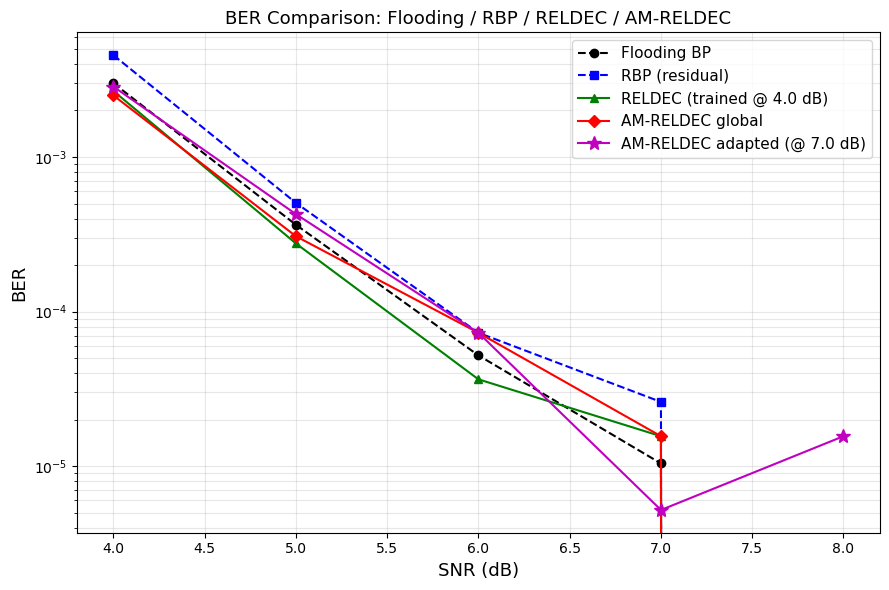

Plot saved to sims/ber_am_reldec.png


In [ ]:
plt.figure(figsize=(9, 6))
plt.semilogy(test_snrs, bers_flood,     'k--o',  label='Flooding BP')
plt.semilogy(test_snrs, bers_rbp,       'b--s',  label='RBP (residual)')
plt.semilogy(test_snrs, bers_reldec,    'g-^',   label=f'RELDEC (trained @ {RELDEC_TRAIN_SNR} dB)')
plt.semilogy(test_snrs, bers_am_global, 'r-D',   label='AM-RELDEC global')
plt.semilogy(test_snrs, bers_am_local,  'm-*',   markersize=10,
             label=f'AM-RELDEC adapted (@ {target_adapt_snr} dB)')

plt.xlabel('SNR (dB)', fontsize=13)
plt.ylabel('BER',      fontsize=13)
plt.title('BER Comparison: Flooding / RBP / RELDEC / AM-RELDEC', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('ber_am_reldec.png', dpi=150)
plt.show()
print('Plot saved to sims/ber_am_reldec.png')

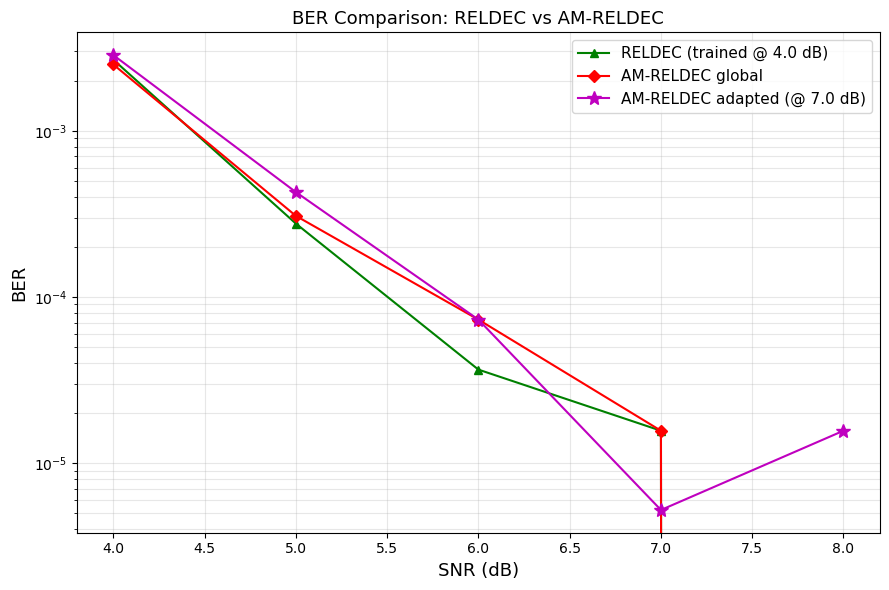

Plot saved to sims/ber_reldec_am_reldec.png


In [ ]:
# plot RELDEC and AM-RELDEC BER vs SNR curves together for comparison
plt.figure(figsize=(9, 6))
plt.semilogy(test_snrs, bers_reldec,    'g-^',   label=f'RELDEC (trained @ {RELDEC_TRAIN_SNR} dB)')
plt.semilogy(test_snrs, bers_am_global, 'r-D',   label='AM-RELDEC global')
plt.semilogy(test_snrs, bers_am_local,  'm-*',   markersize=10,
             label=f'AM-RELDEC adapted (@ {target_adapt_snr} dB)')
plt.xlabel('SNR (dB)', fontsize=13)
plt.ylabel('BER',      fontsize=13)
plt.title('BER Comparison: RELDEC vs AM-RELDEC', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('ber_reldec_am_reldec.png', dpi=150)
plt.show()
print('Plot saved to sims/ber_reldec_am_reldec.png')



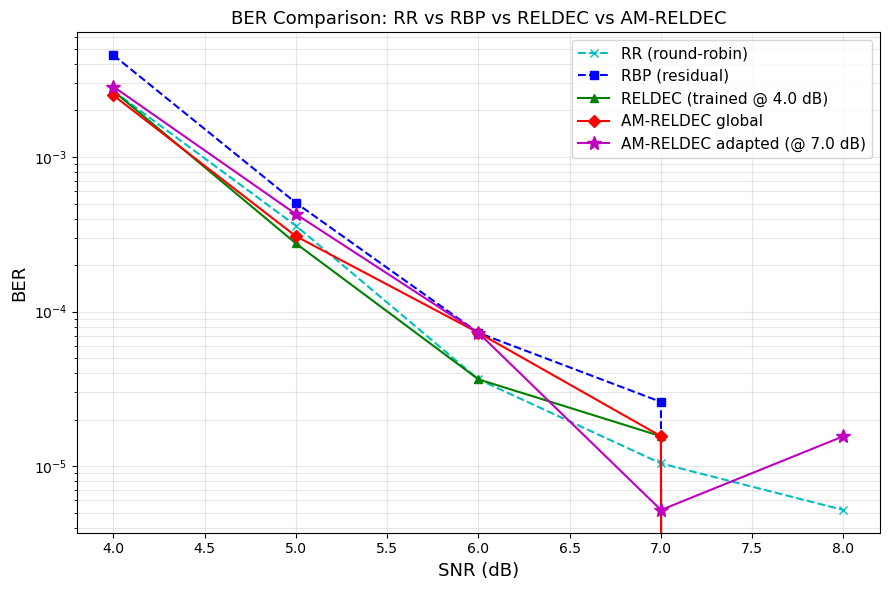

Plot saved to sims/ber_rr_rbp_reldec_am_reldec.png


In [ ]:
# plot reldec vs am-reldec vs rbp vs rr together for comparison
plt.figure(figsize=(9, 6))
plt.semilogy(test_snrs, bers_rr,        'c--x',  label='RR (round-robin)')
plt.semilogy(test_snrs, bers_rbp,       'b--s',  label='RBP (residual)')
plt.semilogy(test_snrs, bers_reldec,    'g-^',   label=f'RELDEC (trained @ {RELDEC_TRAIN_SNR} dB)')
plt.semilogy(test_snrs, bers_am_global, 'r-D',   label='AM-RELDEC global')  
plt.semilogy(test_snrs, bers_am_local,  'm-*',   markersize=10,
             label=f'AM-RELDEC adapted (@ {target_adapt_snr} dB)')
plt.xlabel('SNR (dB)', fontsize=13)
plt.ylabel('BER',      fontsize=13)
plt.title('BER Comparison: RR vs RBP vs RELDEC vs AM-RELDEC', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('ber_rr_rbp_reldec_am_reldec.png', dpi=150)
plt.show()
print('Plot saved to sims/ber_rr_rbp_reldec_am_reldec.png')